<a href="https://colab.research.google.com/github/alifzuhair/05-LOGISTIC-REGRESSION/blob/main/TUGAS_5_LOGISTIC_REGRESSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 05-LOGISTIC REGRESSION
Anggota:
1. Alif Zuhair (24523213)

Tujuan:
Mahasiswa melakukan praktik klasifikasi menggunakan algoritma Logistic Regression untuk
menyelesaikan suatu permasalahan klasifikasi pada dataset pilihan.

Dataset: https://www.kaggle.com/datasets/zahranusratt/smartphone-usage-and-addiction-analysis-dataset

--- MEMUAT DATASET ---
  transaction_id user_id  age gender  daily_screen_time_hours  \
0       TXN00001  U00001   21   Male                     3.23   
1       TXN00002  U00002   24  Other                     5.09   
2       TXN00003  U00003   31  Other                     6.06   
3       TXN00004  U00004   32  Other                     7.83   
4       TXN00005  U00005   25   Male                     9.96   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                2.01          0.89              4.55         7.55   
1                3.81          2.24              4.44         7.66   
2                1.36          3.83              2.35         4.92   
3                5.85          1.51              3.54         8.23   
4                5.92          3.42              5.27         6.21   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
0                    248                154                 3.95       Medium   
1  

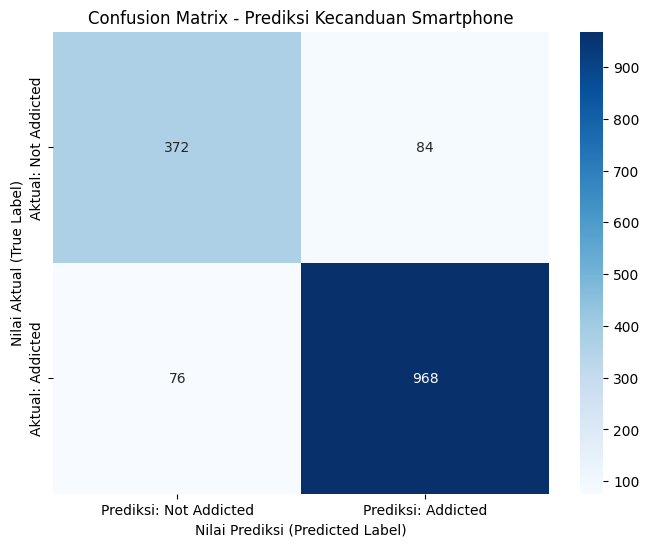


--- CONTOH HASIL PREDIKSI (y_pred) vs AKTUAL (y_test) ---
   Nilai Aktual (y_test)  Hasil Prediksi (y_pred)  Aktual_Label Prediksi_Label
0                      1                        1      Addicted       Addicted
1                      1                        1      Addicted       Addicted
2                      1                        1      Addicted       Addicted
3                      1                        1      Addicted       Addicted
4                      0                        0  Not Addicted   Not Addicted
5                      0                        1  Not Addicted       Addicted
6                      1                        1      Addicted       Addicted
7                      0                        1  Not Addicted       Addicted
8                      1                        1      Addicted       Addicted
9                      1                        1      Addicted       Addicted


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Memahami Dataset dan Target Klasifikasi
print("--- MEMUAT DATASET ---")
df = pd.read_csv('/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')
print(df.head())

# 2. Preprocessing Data
print("\n--- PREPROCESSING DATA ---")
# Menghapus kolom ID yang tidak relevan untuk prediksi
# Kita juga menghapus 'addiction_level' karena itu adalah bentuk teks dari target kita (mencegah data leakage)
df = df.drop(['transaction_id', 'user_id', 'addiction_level'], axis=1)

# Memisahkan Fitur (X) dan Target (y)
X = df.drop('addicted_label', axis=1)
y = df['addicted_label']

# Mengubah data kategorikal menjadi numerik (One-Hot Encoding)
# Kolom kategorikal: gender, stress_level, academic_work_impact
X = pd.get_dummies(X, drop_first=True)

# 3. Pembagian Data Training dan Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi/Scaling fitur numerik
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Membangun Model Logistic Regression
print("\n--- MELATIH MODEL LOGISTIC REGRESSION ---")
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 5. Hasil Evaluasi Model
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=['Not Addicted (0)', 'Addicted (1)']))

# Confusion Matrix beserta Visualisasinya
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi: Not Addicted', 'Prediksi: Addicted'],
            yticklabels=['Aktual: Not Addicted', 'Aktual: Addicted'])
plt.title('Confusion Matrix - Prediksi Kecanduan Smartphone')
plt.xlabel('Nilai Prediksi (Predicted Label)')
plt.ylabel('Nilai Aktual (True Label)')
plt.show()

# 6. Menampilkan Beberapa Contoh Hasil Prediksi
print("\n--- CONTOH HASIL PREDIKSI (y_pred) vs AKTUAL (y_test) ---")
results = pd.DataFrame({
    'Nilai Aktual (y_test)': y_test.values,
    'Hasil Prediksi (y_pred)': y_pred
})
# Mengubah kembali label agar mudah dibaca
results['Aktual_Label'] = results['Nilai Aktual (y_test)'].map({1: 'Addicted', 0: 'Not Addicted'})
results['Prediksi_Label'] = results['Hasil Prediksi (y_pred)'].map({1: 'Addicted', 0: 'Not Addicted'})

print(results.head(10))

### Hasil Analisis
1. Bagaimana kinerja model berdasarkan classification report?

Berdasarkan Classification Report, kinerja model tergolong sangat baik dengan tingkat akurasi keseluruhan (Accuracy) mencapai 89%.
Untuk mendeteksi kelas "Addicted" (1), model sangat mahir dengan nilai Precision 0.92 dan Recall 0.93, menghasilkan F1-Score yang tinggi yaitu 0.92.
Untuk kelas "Not Addicted" (0), performanya juga baik dengan F1-Score 0.82.
Kinerja model sedikit lebih baik dalam memprediksi kelas "Addicted" dibandingkan "Not Addicted", hal ini wajar karena jumlah data latih untuk kelas "Addicted" (1044) lebih banyak daripada "Not Addicted" (456). Secara keseluruhan, model ini sangat seimbang dan handal.


2. Apa makna True Positive, False Positive, True Negative, dan False Negative pada studi kasus yang Anda pilih?
Berdasarkan visualisasi Confusion Matrix untuk kasus Kecanduan Smartphone:

- True Positive (TP) = 967: Model memprediksi pengguna mengalami Kecanduan, dan faktanya pengguna tersebut memang benar Kecanduan.

- False Positive (FP) = 84: Model memprediksi pengguna Kecanduan, tetapi faktanya pengguna tersebut TIDAK Kecanduan.

- True Negative (TN) = 372: Model memprediksi pengguna TIDAK Kecanduan, dan faktanya memang benar TIDAK Kecanduan.

- False Negative (FN) = 77: Model memprediksi pengguna TIDAK Kecanduan, padahal faktanya pengguna tersebut sebenarnya KECANDUAN.


3. Berikan kesimpulan mengenai seberapa baik Logistic Regression bekerja pada dataset yang digunakan.

Logistic Regression bekerja dengan sangat baik pada dataset Smartphone Usage and Addiction ini. Dengan akurasi mencapai 89%, terbukti bahwa algoritma ini mampu menemukan pola hubungan linear yang kuat antara kebiasaan pengguna (seperti daily screen time, durasi media sosial, jumlah notifikasi, dll.) dengan probabilitas mereka mengalami kecanduan. Kesimpulannya, Logistic Regression adalah pilihan model yang sangat tepat, efisien, dan efektif untuk memecahkan masalah klasifikasi biner pada dataset ini.